In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]

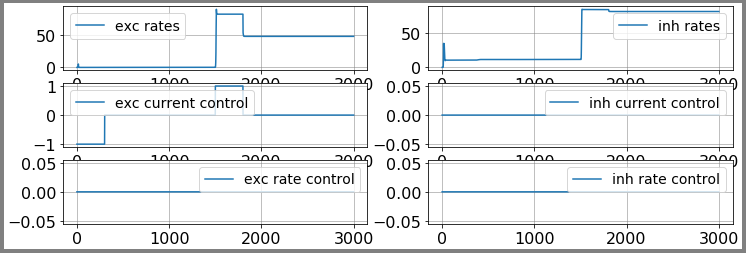

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


In [3]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]

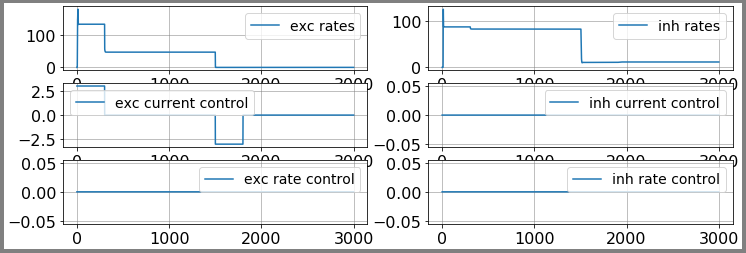

low state vars =  [ 8.2469e-02  1.1638e+01  4.3314e-01  7.5957e-01  0.0000e+00  1.6029e-02
  6.3812e-01  1.4997e-02  7.8014e-01  9.5893e-04  6.6523e-03  8.4016e-04
  6.5247e-03  0.0000e+00  0.0000e+00  7.1463e-01  5.5403e-01 -5.6298e+01
  2.7100e+01  6.3823e+00]


In [4]:
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]

print("low state vars = ", low_state_vars)

# A: Scenarios

scenario | control variables | precision measure
---------|--------------|-----------
A.0 | 0 | 0
B.1 | 1 | 1
B.2 | 2 | 0
B.3 | 0 | 1
B.4 | 1 | 0
B.5 | 2 | 1
B.6 | 0, 1 | 0
B.7 | 0, 1 | 1
B.8 | 0, 2 | 0
B.9 | 0, 2 | 1
B.10 | 1, 2 | 0
B.11 | 1, 2 | 1
B.12 | 0, 1, 2 | 0
B.13 | 0, 1, 2 | 1
B.14 | 0 | 0,1
B.15 | 1 | 0,1
B.16 | 2 | 0,1
B.17 | 0,1 | 0,1
B.18 | 0,2 | 0,1
B.19 | 1,2 | 0,1
B.20 | 0,1,2 | 0,1

In [5]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 5000

initVars = high_state_vars

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = [0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 
                    0.8, 0.8, 0.8, 0.8, 0.8 ]

sheet = "B"

target_rates = np.array( [steady_rates[1,0], steady_rates[1,1]])

In [6]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
    elif cntrl_vars == [1]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [2]:
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
            
    return max_cntrl, min_cntrl        

In [7]:
dur = 300
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

## 1

set cost params
control input:  [1] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.10539675394766683
RUN  1 , total integrated cost =  0.10510125033077565
RUN  2 , total integrated cost =  0.10480720606500235
RUN  3 , total integrated cost =  0.10451466482119671
RUN  4 , total integrated cost =  0.10422332940686116
RUN  5 , total integrated cost =  0.10392797537354187
RUN  6 , total integrated cost =  0.10363290353767306
RUN  7 , total integrated cost =  0.10333459415850431
RUN  8 , total integrated cost =  0.10304620480920118
RUN  9 , total integrated cost =  0.1027590579721682
RUN  10 , total integrated cost =  0.10246511147899137
RUN  11 , total integrated cost =  0.10217540445057784
RUN  12 , total integrated cost =  0.1018901009658939
RUN  13 , total integrated cost =  0.10160954572115823
RUN  14 , total integrated cost =  0.10133034730271474
RUN  15 , total integrated cost =  0.10105254913342575
RUN  16 , total integrated cost 

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  0.013141575769751494
RUN  1000 , total integrated cost =  0.013141575769751494
Improved over  1000  iterations by  87.53132778996519  percent.
Problem in initial value trasfer:  Vmean_exc -56.41291532553057 -56.41290805320807


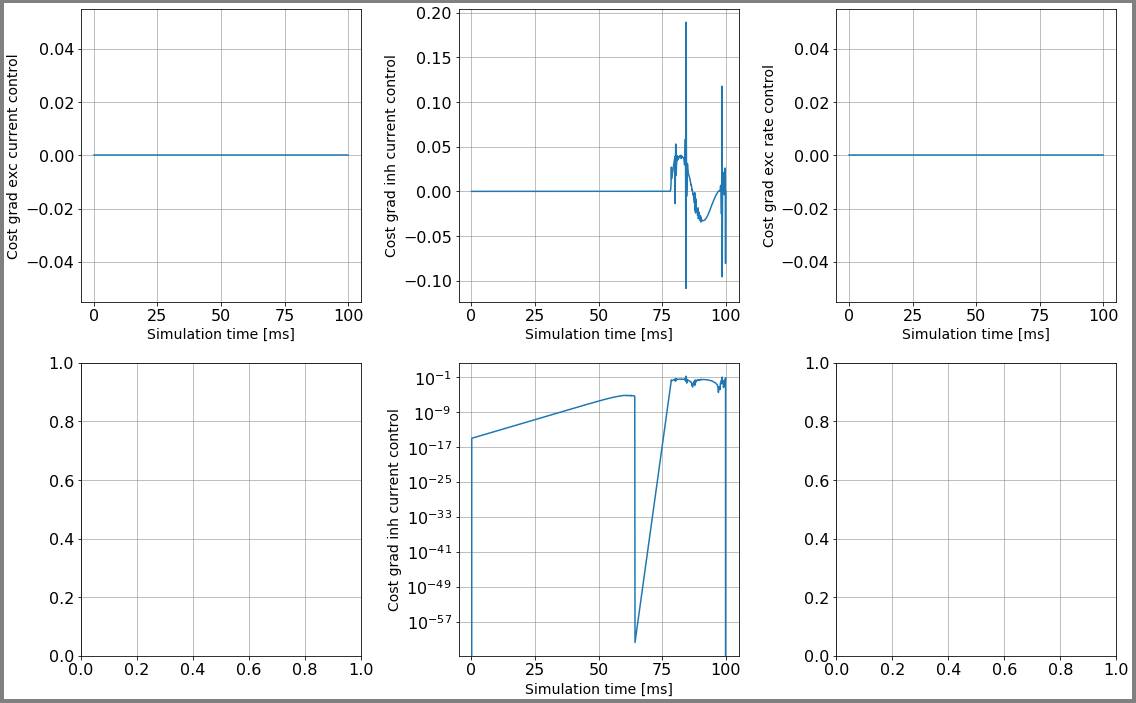

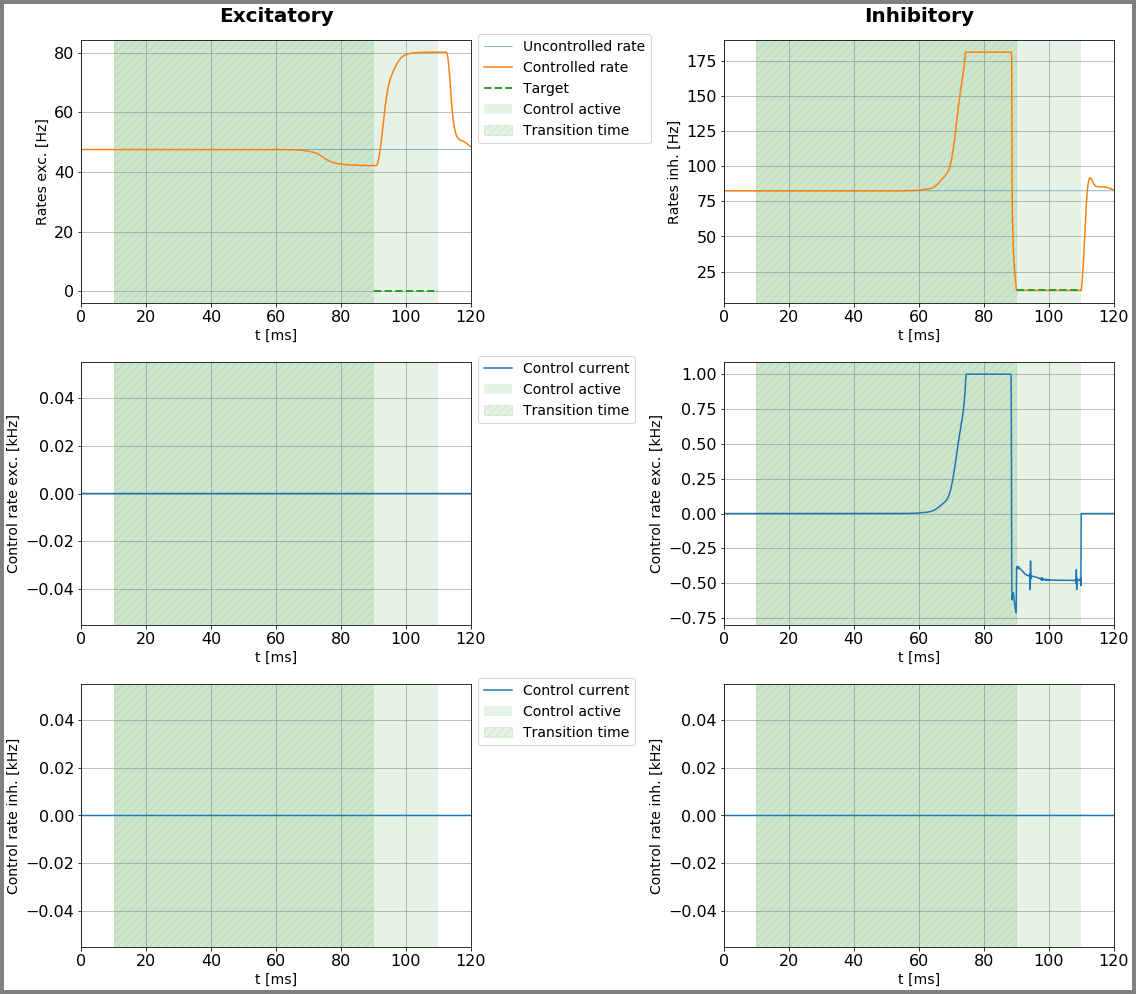

In [96]:
# B.1.a)

case_ind = 1
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]
#for i in range(bestStatea.shape[2]-n_pre-n_post):
#    print(i, control1[0,1,i], bestStatea[0,3,i-n_pre])
#    if bestStatea[0,3,i-n_pre] >= 7.:
#        print(i)
#        control1[0,1,i] = 0.

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 1000

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [78]:
print(bestStatea[0,1,1000:1100])
print(bestStatea[0,3,1000:1100])

[2.77226176e-13 2.19376563e-13 1.66161797e-13 1.17277188e-13
 7.24363884e-14 3.25386503e-14 2.72236882e-14 2.23189799e-14
 1.77979158e-14 1.36353935e-14 9.80794938e-15 6.29342059e-15
 3.07115195e-15 2.19236314e-15 1.82830758e-15 1.49215485e-15
 1.18214579e-15 8.96574448e-16 6.33831785e-16 3.92436262e-16
 1.75002121e-16 1.49298541e-16 1.25512037e-16 1.03519800e-16
 8.32068544e-17 6.44676178e-17 4.71980081e-17 3.13047621e-17
 1.66975560e-17 1.02268600e-17 8.74227666e-18 7.36720825e-18
 6.09425386e-18 4.91738241e-18 3.83009341e-18 2.82709102e-18
 1.90267188e-18 1.05197285e-18 6.03505888e-19 5.21434275e-19
 4.45231847e-19 3.74603847e-19 3.09132305e-19 2.48560268e-19
 1.92512580e-19 1.40768728e-19 9.29963253e-20 4.89893711e-20
 3.12466972e-20 2.72089830e-20 2.34423002e-20 1.99546703e-20
 1.67031224e-20 1.37003947e-20 1.09024680e-20 8.32537037e-21
 5.92690679e-21 3.72207258e-21 1.67640845e-21 1.44406441e-21
 1.26165318e-21 1.09907093e-21 9.39284917e-22 7.99841076e-22
 6.59847596e-22 5.408322

ERROR:root:Problem in initial value trasfer


set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  2405.630181669693
RUN  2 , total integrated cost =  2065.3096112378157
RUN  3 , total integrated cost =  2018.7139323857873
RUN  3 , total integrated cost =  2018.7139323857873
Improved over  3  iterations by  95.96968114908518  percent.
Problem in initial value trasfer:  Vmean_exc -56.39336704945389 -56.39339015503422


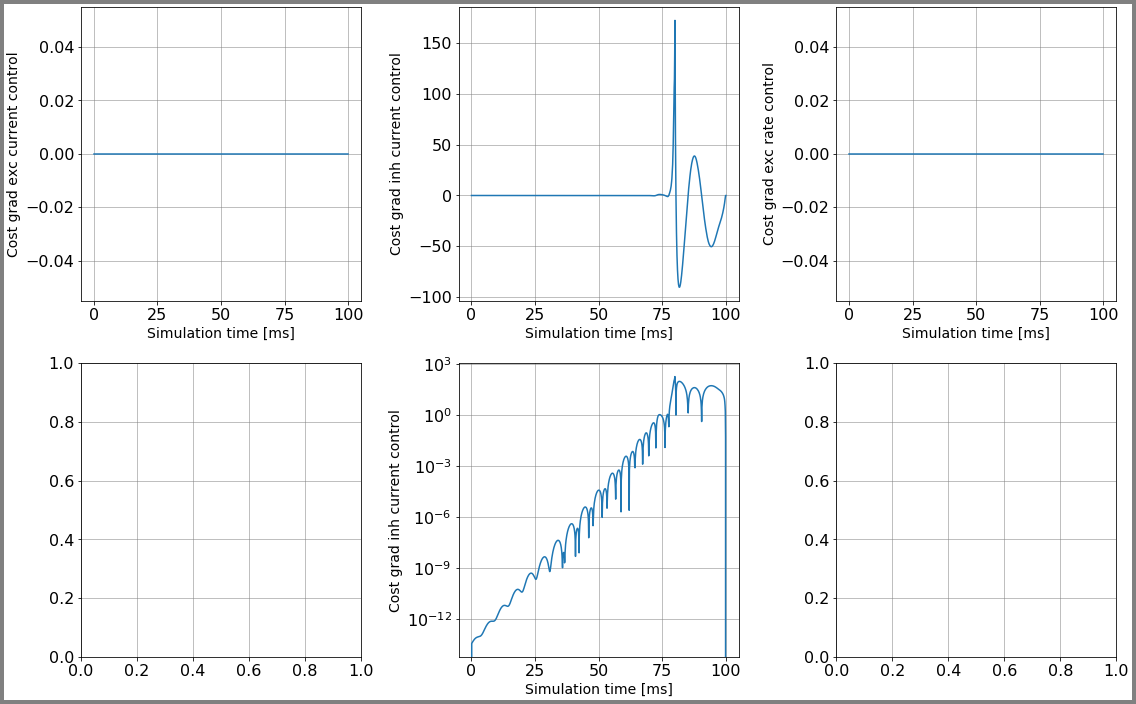

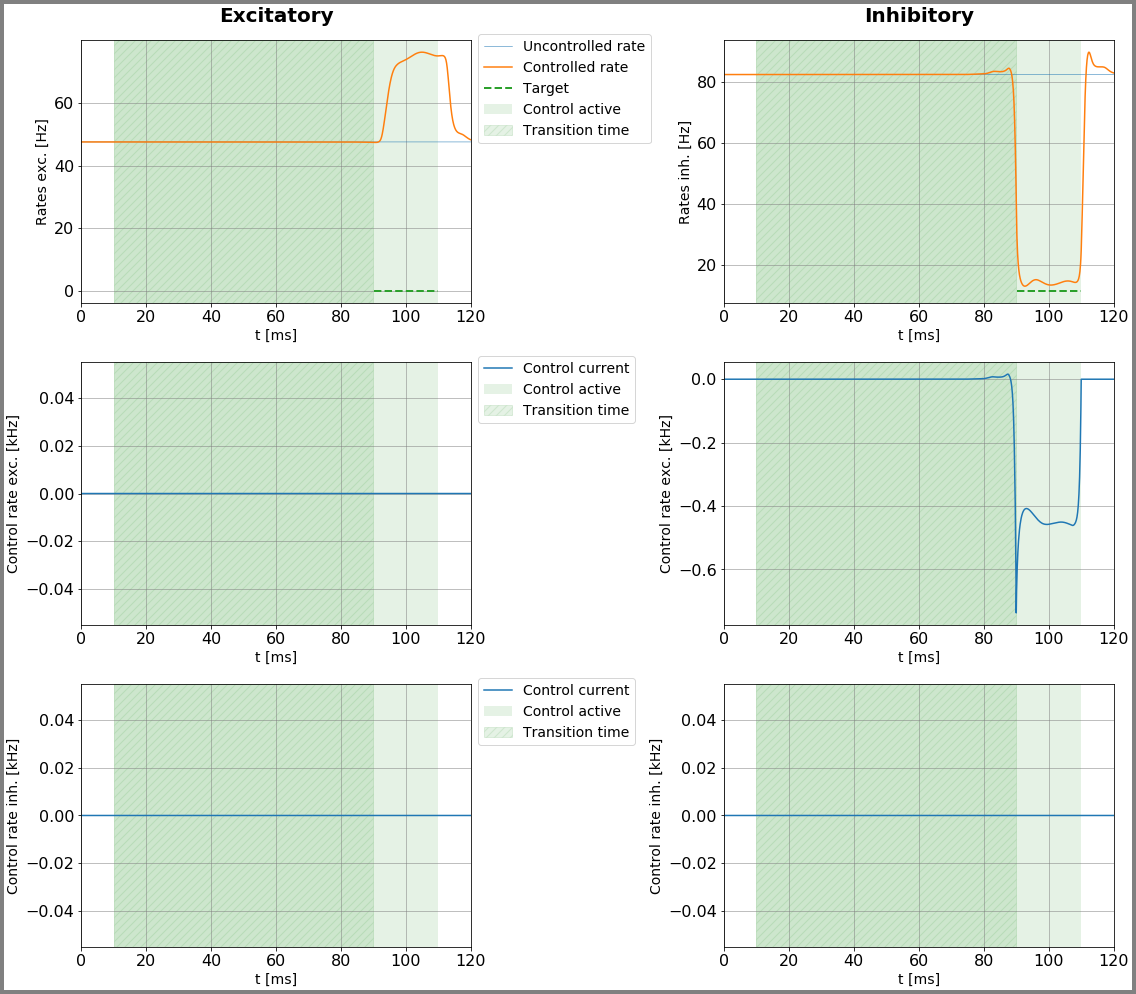

In [69]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case_ind = 1
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 3

set cost params
control input:  [0] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.986279032376128
should never be the case
should never be the case
n_dt de =  40
jac 7 =  [-0.09230764 -0.09230764 -0.09230764 -0.09230764 -0.09230765 -0.09230765
 -0.09230765 -0.09230765 -0.09230766 -0.09230766 -0.09230766 -0.09230766
 -0.09230766 -0.09230766 -0.09230767 -0.09230767 -0.09230767 -0.09230767
 -0.09230767 -0.09230767 -0.09230767 -0.09230767 -0.09230767 -0.09230768
 -0.09230768 -0.09230768 -0.09230768 -0.09230768 -0.09230768 -0.09230768
 -0.09230768 -0.09230768 -0.09230768 -0.09230768 -0.09230768 -0.09230768
 -0.09230768 -0.09230768 -0.09230768 -0.09230768 -0.09230769 -0.09230769
 -0.09230769 -0.09230769 -0.09230769 -0.09230769 -0.09230769 -0.09230769
 -0.09230769 -0.09230769 -0.09230769 -0.09230769 -0.09230769 -0.09230769
 -0.09230769 -0.09230769 -0.09230769 -0.09230769 -0.09230769 -0.09230769
 -0.09230769 -0.09230769 -0.09230769 -0.09230

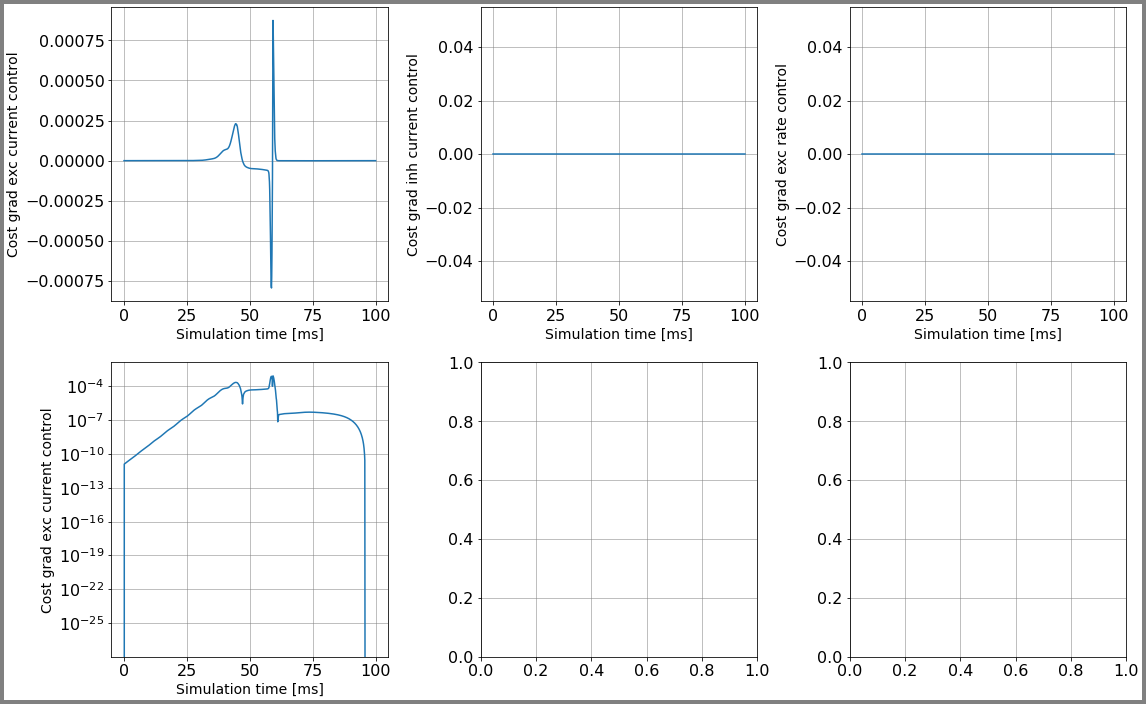

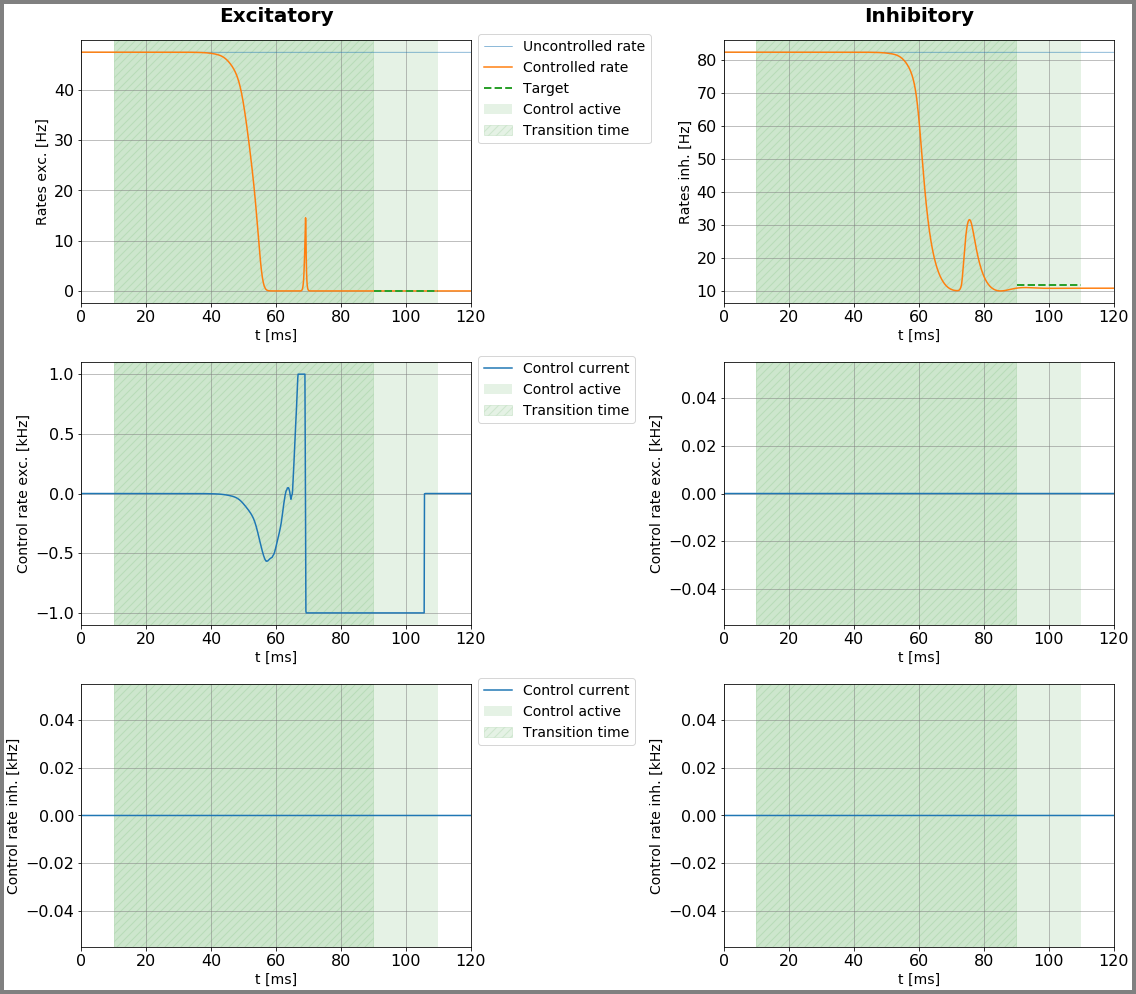

In [65]:
case_ind = 3
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 3

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

1.5604314662830605e-37
(1, 20, 1201)


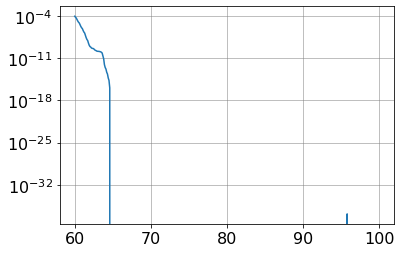

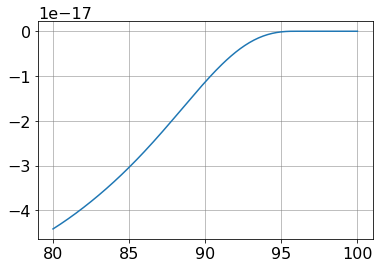

In [64]:
max_grad = np.amax(grada[0,0,693:])
print(max_grad)
print(bestStatea.shape)

plt.plot(np.arange(60, 100.1,0.1), grada[0,0,600:])
plt.yscale('log')
plt.show()

plt.plot(np.arange(80, 100.1,0.1), grada[0,0,800:])
#plt.yscale('log')
plt.show()


set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  4814.871052014535
RUN  2 , total integrated cost =  2835.4205728140496
RUN  3 , total integrated cost =  619.5551640702577
RUN  3 , total integrated cost =  619.5551640702577
Improved over  3  iterations by  98.7630714699715  percent.
Problem in initial value trasfer:  Vmean_exc -60.385341150727 -60.369577016221875


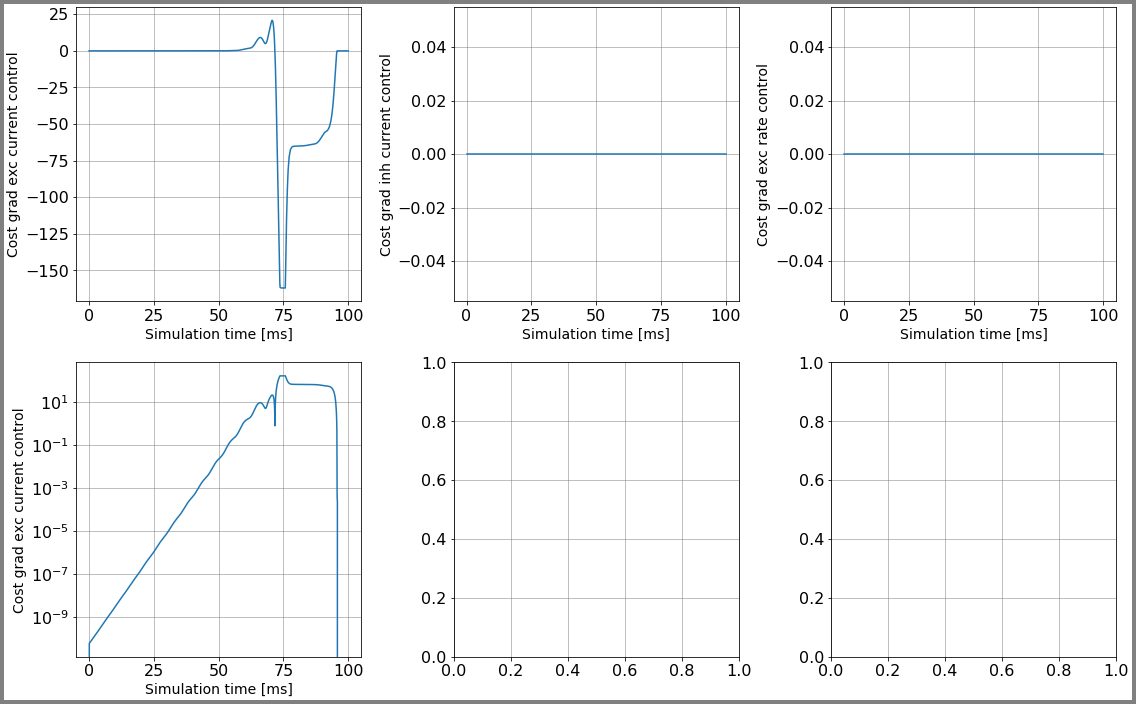

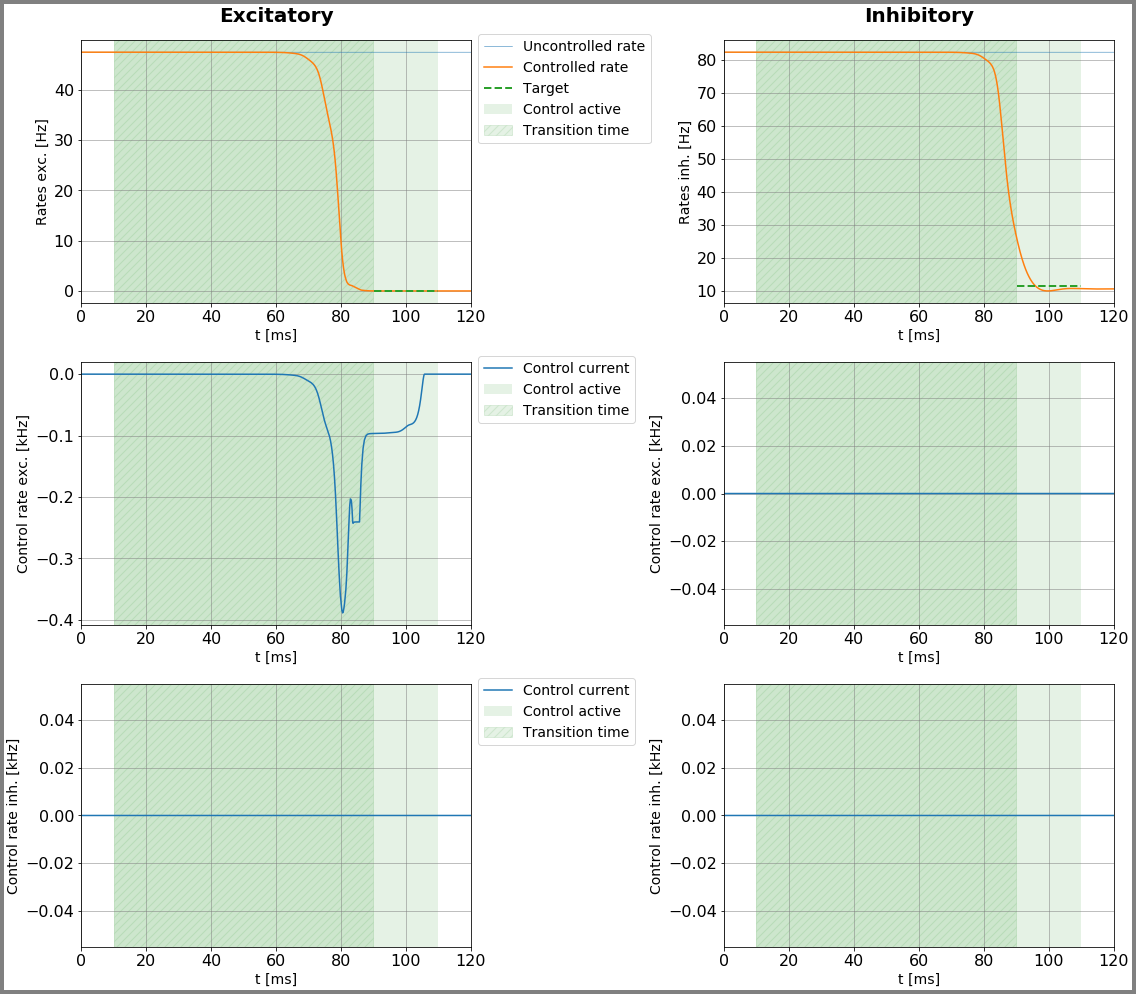

In [66]:
case_ind = 3
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 5

set cost params
control input:  [2] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  50088.1941866105
Control only changes marginally.
RUN  1 , total integrated cost =  50088.1941866105
Improved over  1  iterations by  0.0  percent.


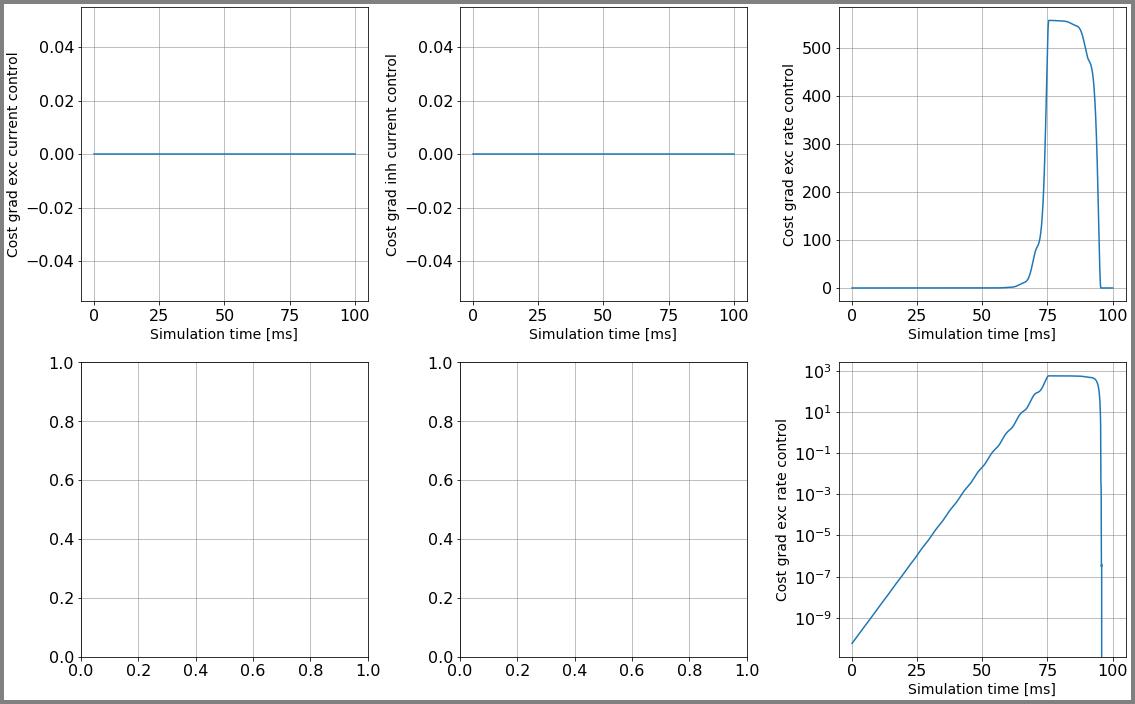

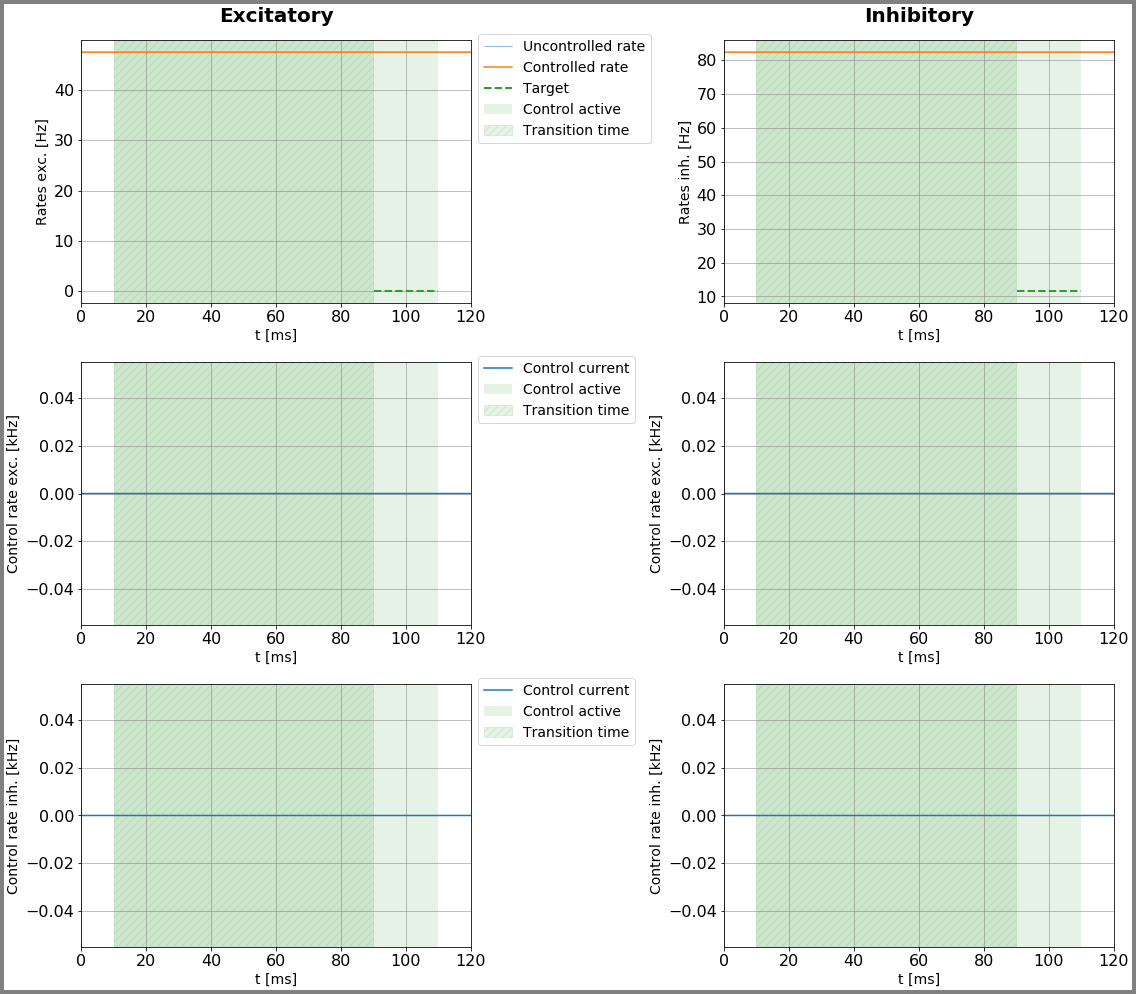

In [67]:
# B.5.a)

case_ind = 5
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  20713.97859171807
RUN  2 , total integrated cost =  20701.050679324457
RUN  3 , total integrated cost =  20700.7943291295
RUN  4 , total integrated cost =  20700.757542450257
RUN  5 , total integrated cost =  20700.749812818056
RUN  6 , total integrated cost =  20700.742311478356
RUN  7 , total integrated cost =  20700.73844357013
RUN  8 , total integrated cost =  20700.738374051147
RUN  9 , total integrated cost =  20700.737890955934
RUN  10 , total integrated cost =  20700.73655393961
RUN  11 , total integrated cost =  20700.736217142225
RUN  12 , total integrated cost =  20700.7356714599
RUN  13 , total integrated cost =  20700.735610154323
RUN  14 , total integrated cost =  20700.735378946294
RUN  15 , total integrated cost =  20700.735146926905
RUN  16 , total integrated cost =  20700.735095621214
RUN  17 , total integrated cost =  20700.7349

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  24 , total integrated cost =  20700.73435700526
Improved over  24  iterations by  7.970126721010942  percent.
Problem in initial value trasfer:  Vmean_exc -56.13984838129106 -56.141369803786674


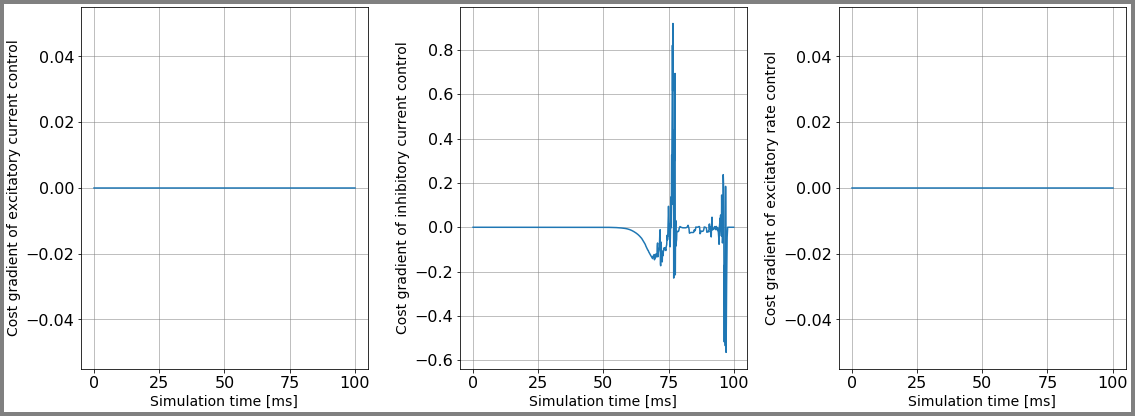

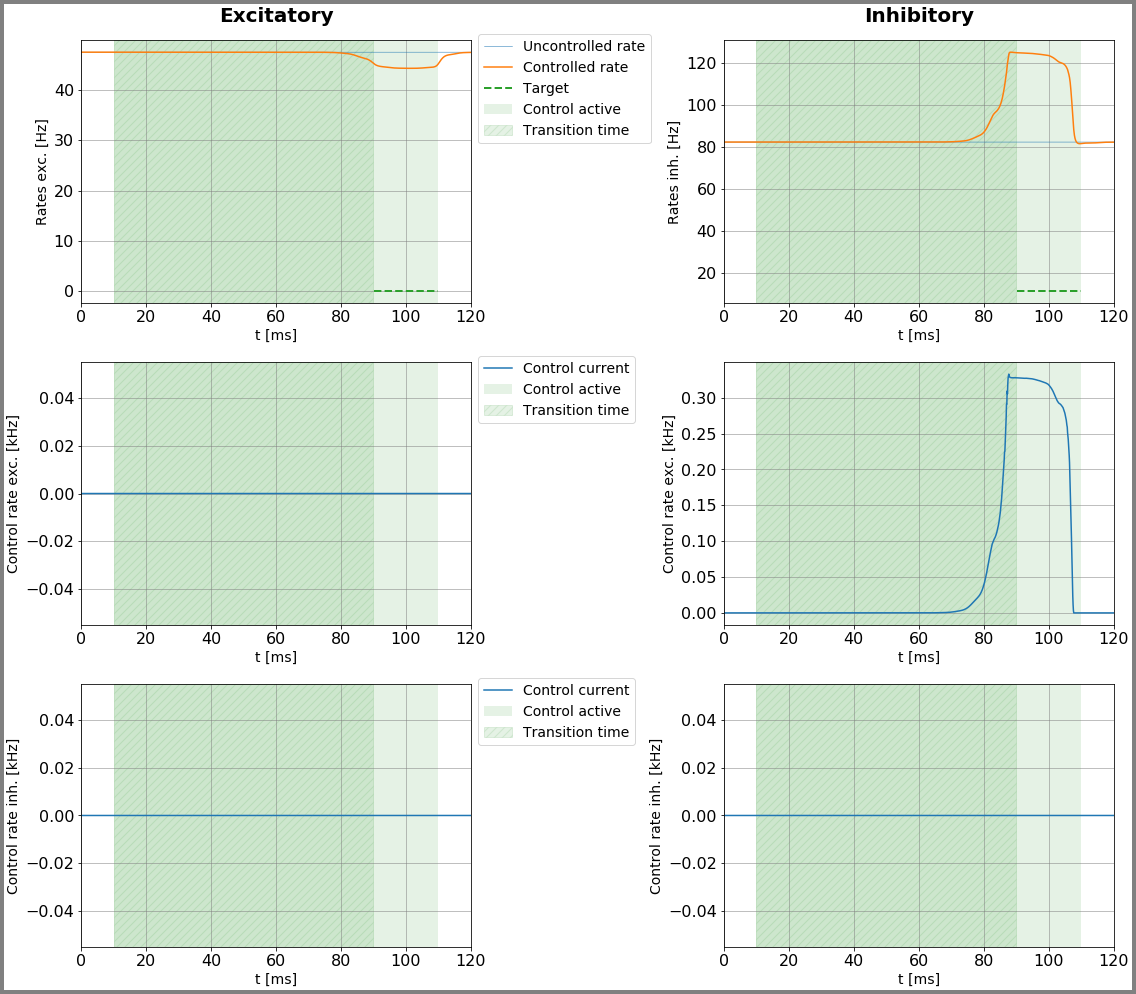

In [12]:
case_ind = 5
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 7

set cost params
control input:  [0, 1] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.455337345878448e-06
Gradient descend method:  HS
RUN  1 , total integrated cost =  3.4357924792258345e-07
RUN  2 , total integrated cost =  7.743847133588363e-08
RUN  3 , total integrated cost =  3.59996785594083e-08
RUN  4 , total integrated cost =  1.7007704667261034e-08
RUN  5 , total integrated cost =  1.1101186959173215e-08
RUN  6 , total integrated cost =  7.827061565372179e-09
RUN  7 , total integrated cost =  4.531372232073348e-09
RUN  8 , total integrated cost =  3.2169758117993213e-09
RUN  9 , total integrated cost =  2.5075150353057648e-09
RUN  10 , total integrated cost =  1.925876187586196e-09
RUN  11 , total integrated cost =  1.4596920021742163e-09
RUN  12 , total integrated cost =  1.0891297712369245e-09
RUN  13 , total integrated cost =  8.924242694294961e-10
RUN  14 , total integrated cost =  7.527035753205969e-10
RUN  15 , total i

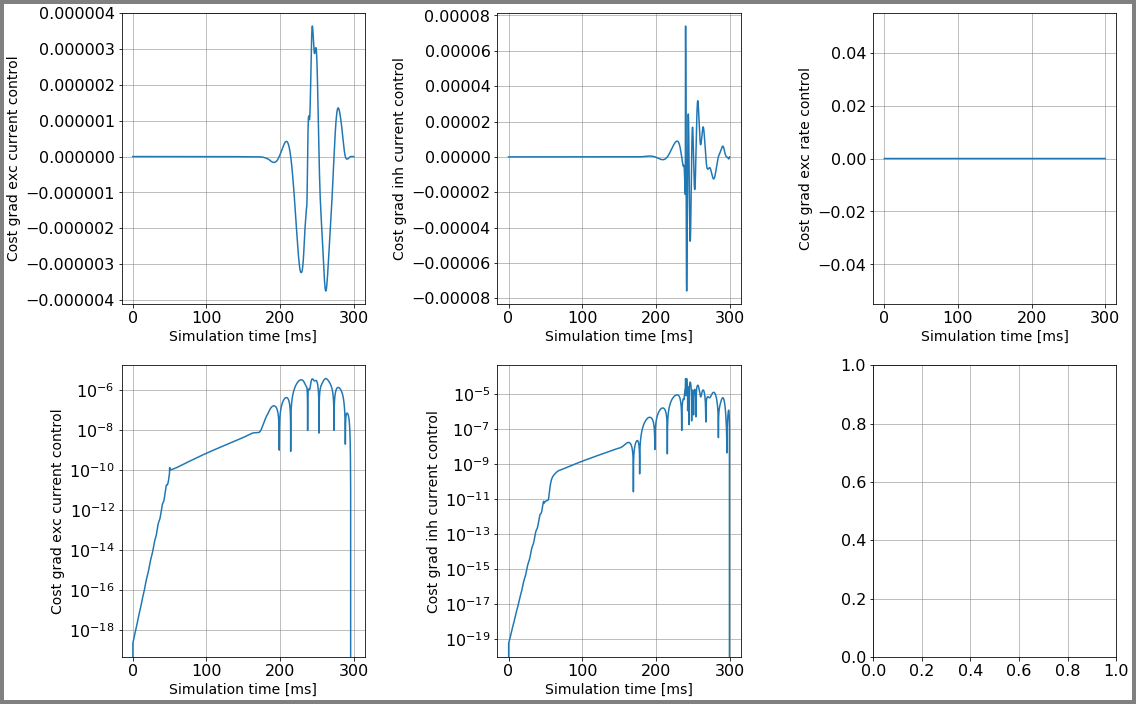

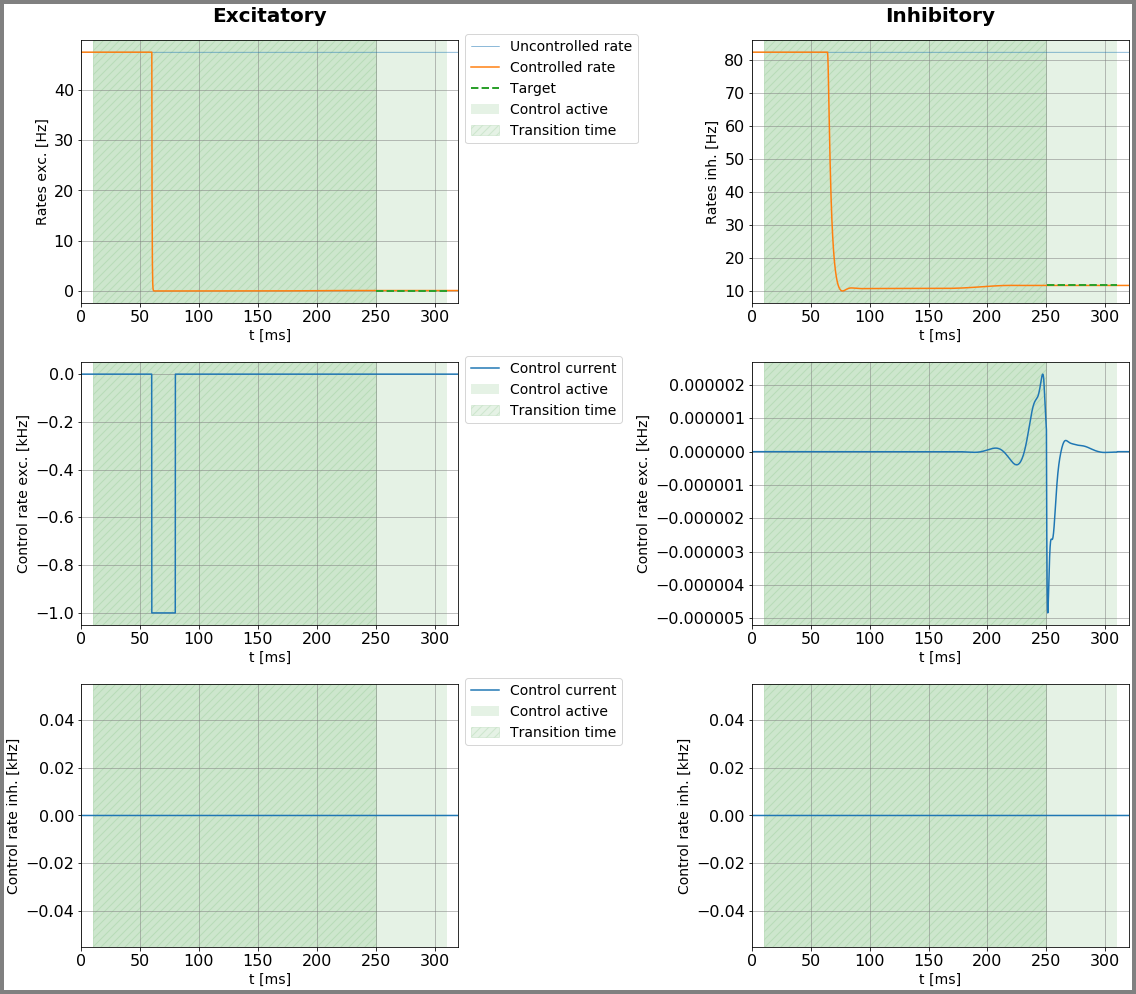

In [11]:
# A.6.a)
case_ind = 7
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,500:700] = -5.
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = "HS"
max_it = 20

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  762.6921895310857
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  762.6921895310857
Control only changes marginally.
RUN  1 , total integrated cost =  762.6921895310857
Improved over  1  iterations in  1.0189758999999867  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.29839467884149 -56.29839389030395


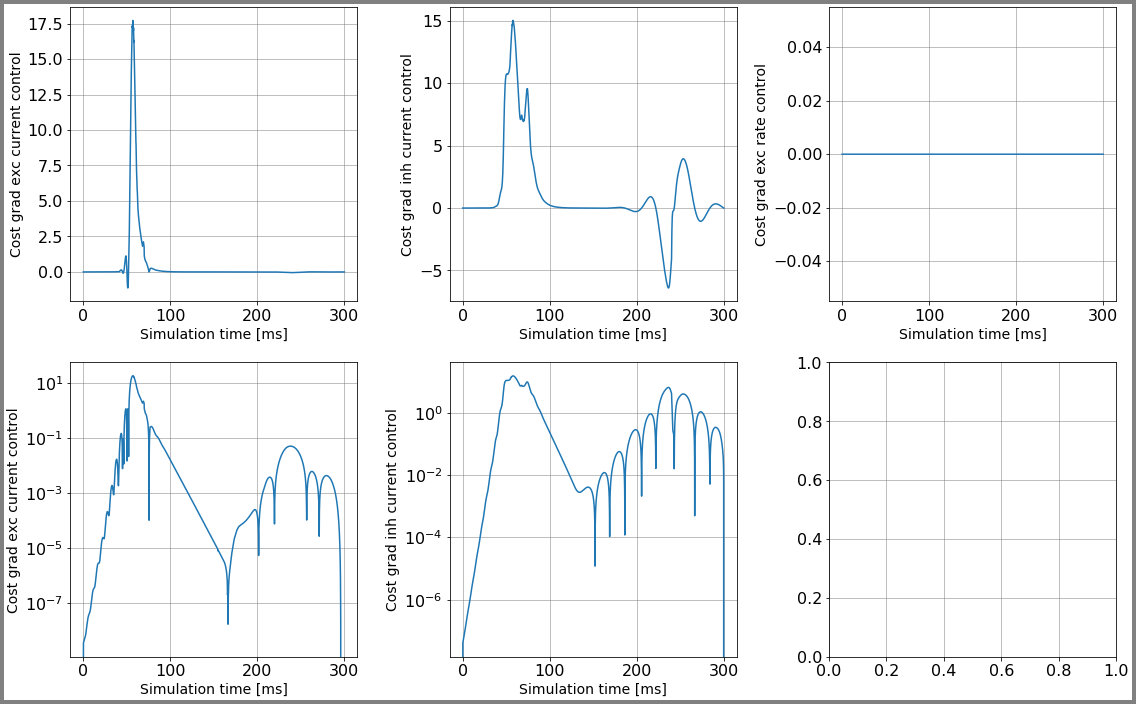

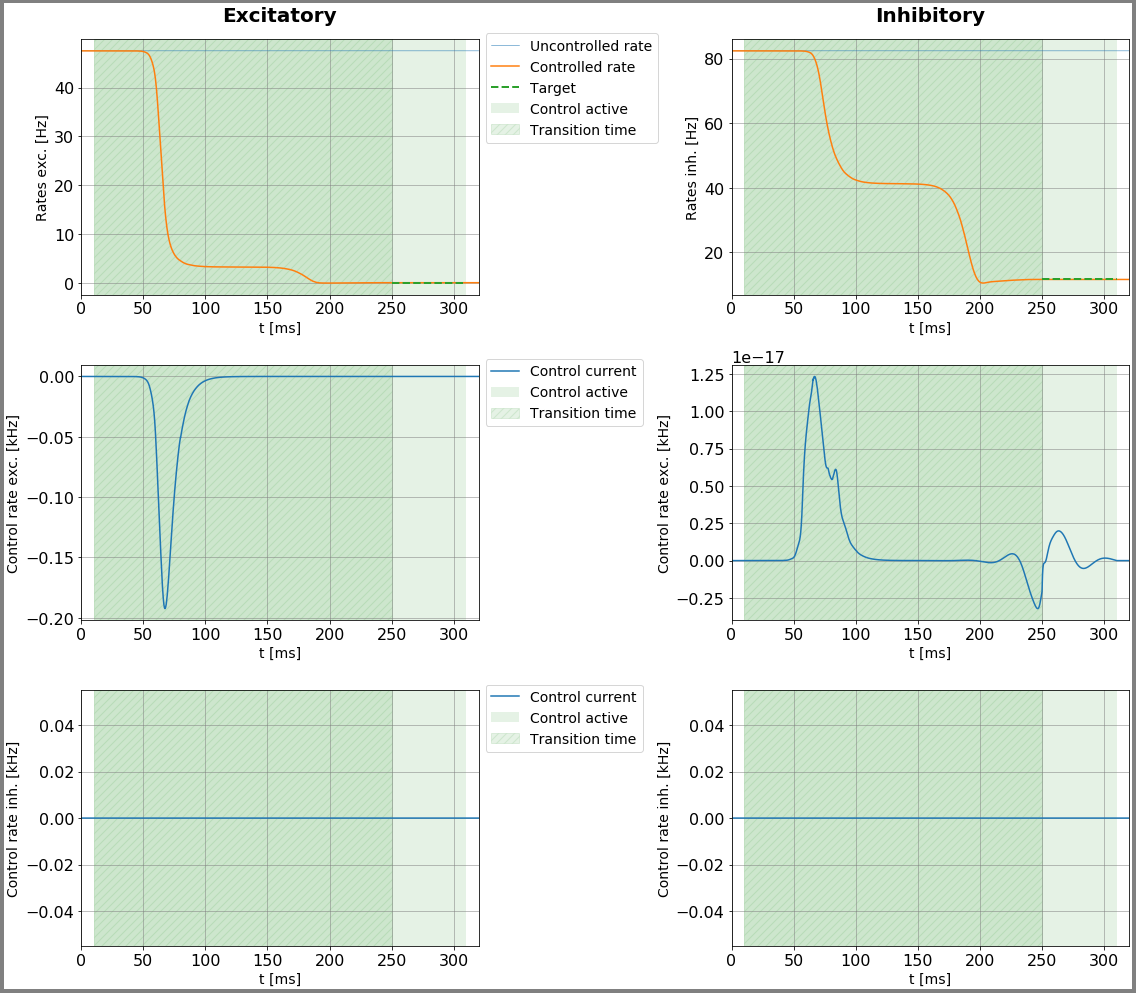

In [16]:
case_ind = 7
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = None
max_it = 100

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 9

set cost params
control input:  [0, 2] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6.331442511930488e-13
RUN  1 , total integrated cost =  1.272362863934792e-13
RUN  2 , total integrated cost =  8.69601288844541e-14
RUN  3 , total integrated cost =  6.722408154875785e-14
RUN  4 , total integrated cost =  5.251120998739248e-14
RUN  5 , total integrated cost =  4.37947752169444e-14
RUN  6 , total integrated cost =  3.6640433258372766e-14
RUN  7 , total integrated cost =  3.172716295395436e-14
RUN  8 , total integrated cost =  2.770569278825255e-14
RUN  9 , total integrated cost =  2.4509647371293795e-14
RUN  10 , total integrated cost =  2.1900750454317586e-14
RUN  11 , total integrated cost =  1.9790318236563056e-14
RUN  12 , total integrated cost =  1.7984771144337093e-14
RUN  13 , total integrated cost =  1.6520210302107182e-14
RUN  14 , total integrated cost =  1.5206144404824956e-14
RUN  15 , total integrated cost =  1.4139106893

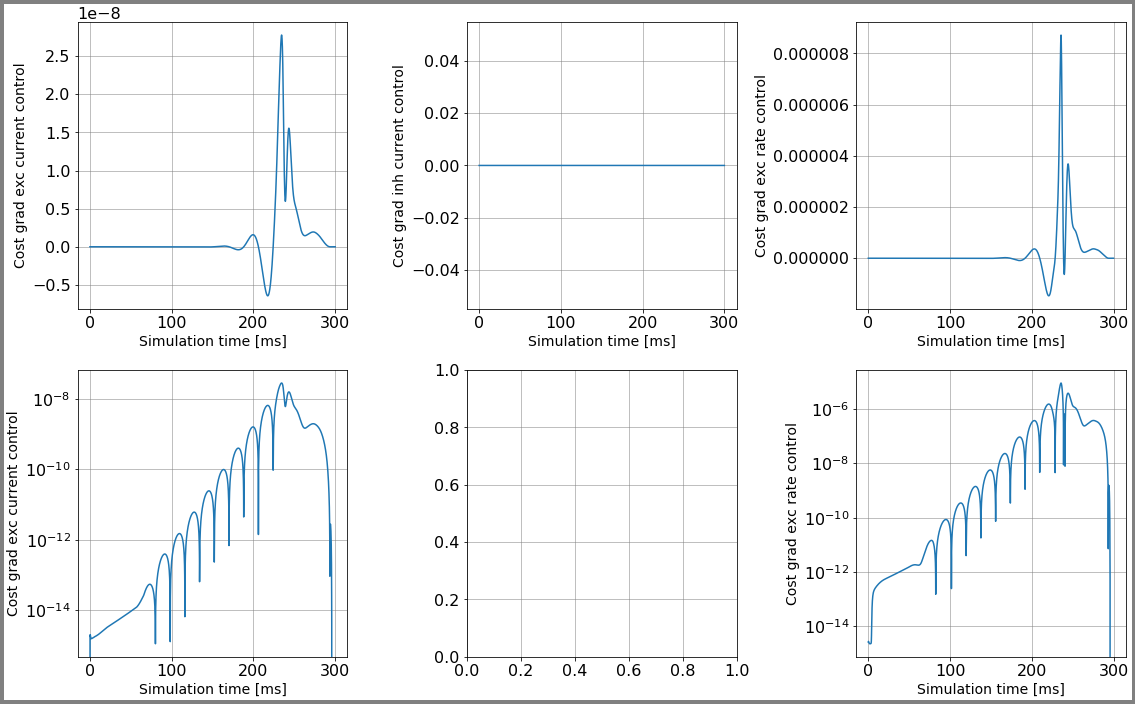

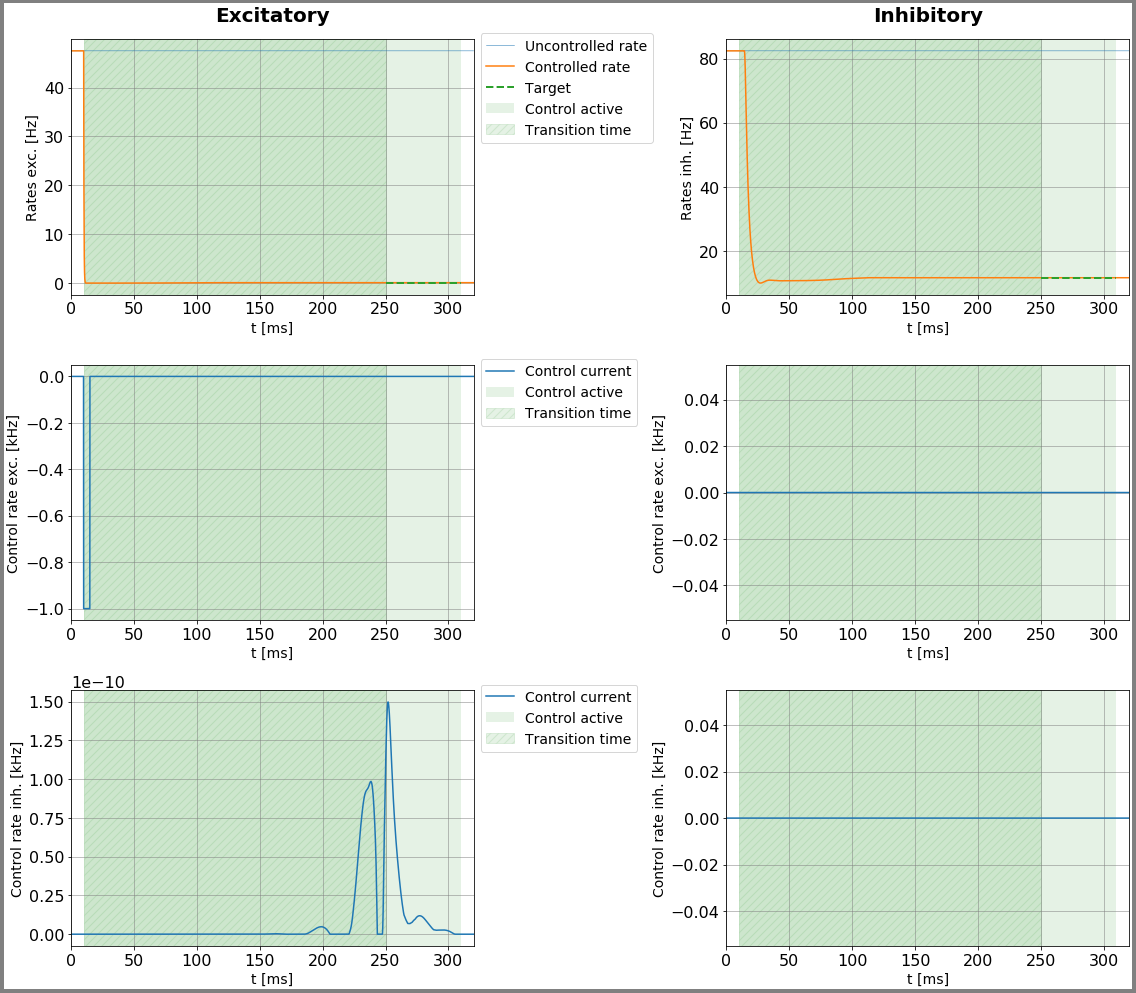

In [115]:
# A.8.a)
case_ind = 9
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,0:50] = -5.
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 100

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  973.1494953914903
RUN  2 , total integrated cost =  723.7835266402074
RUN  3 , total integrated cost =  505.6419230191318
RUN  4 , total integrated cost =  450.66162414833434
RUN  5 , total integrated cost =  394.1221705582965
RUN  6 , total integrated cost =  371.44744577860035
RUN  7 , total integrated cost =  351.69352081768744
RUN  8 , total integrated cost =  341.1141172895118
RUN  9 , total integrated cost =  332.2077359764999
RUN  10 , total integrated cost =  326.70378610383216
RUN  11 , total integrated cost =  321.4449207744851
RUN  12 , total integrated cost =  318.0532952837113
RUN  13 , total integrated cost =  314.3555010291499
RUN  14 , total integrated cost =  312.19631432253806
RUN  15 , total integrated cost =  309.40676860740507
RUN  16 , total integrated cost =  307.5112010333213
RUN  17 , total integrated cost =  305.452471691

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1197 , total integrated cost =  231.8191673924916
Improved over  1197  iterations by  98.96939460065327  percent.
Problem in initial value trasfer:  Vmean_exc -57.15494658346237 -57.15274376866155


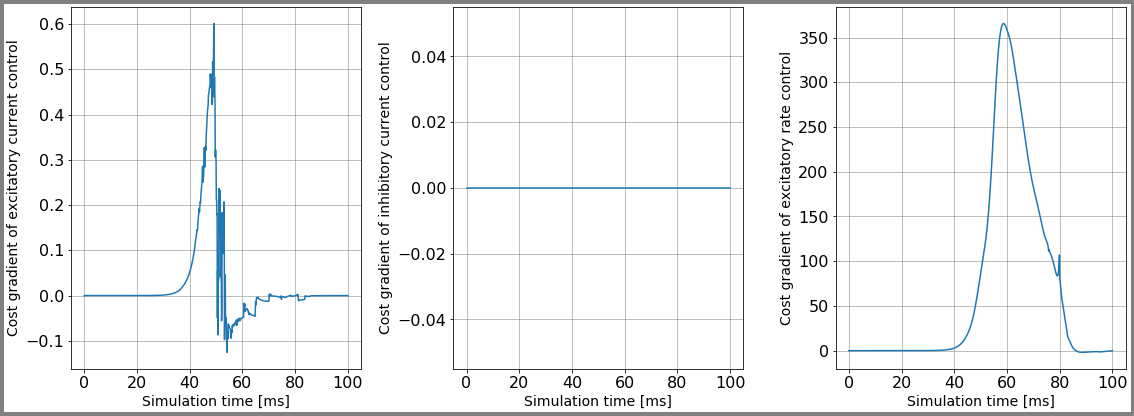

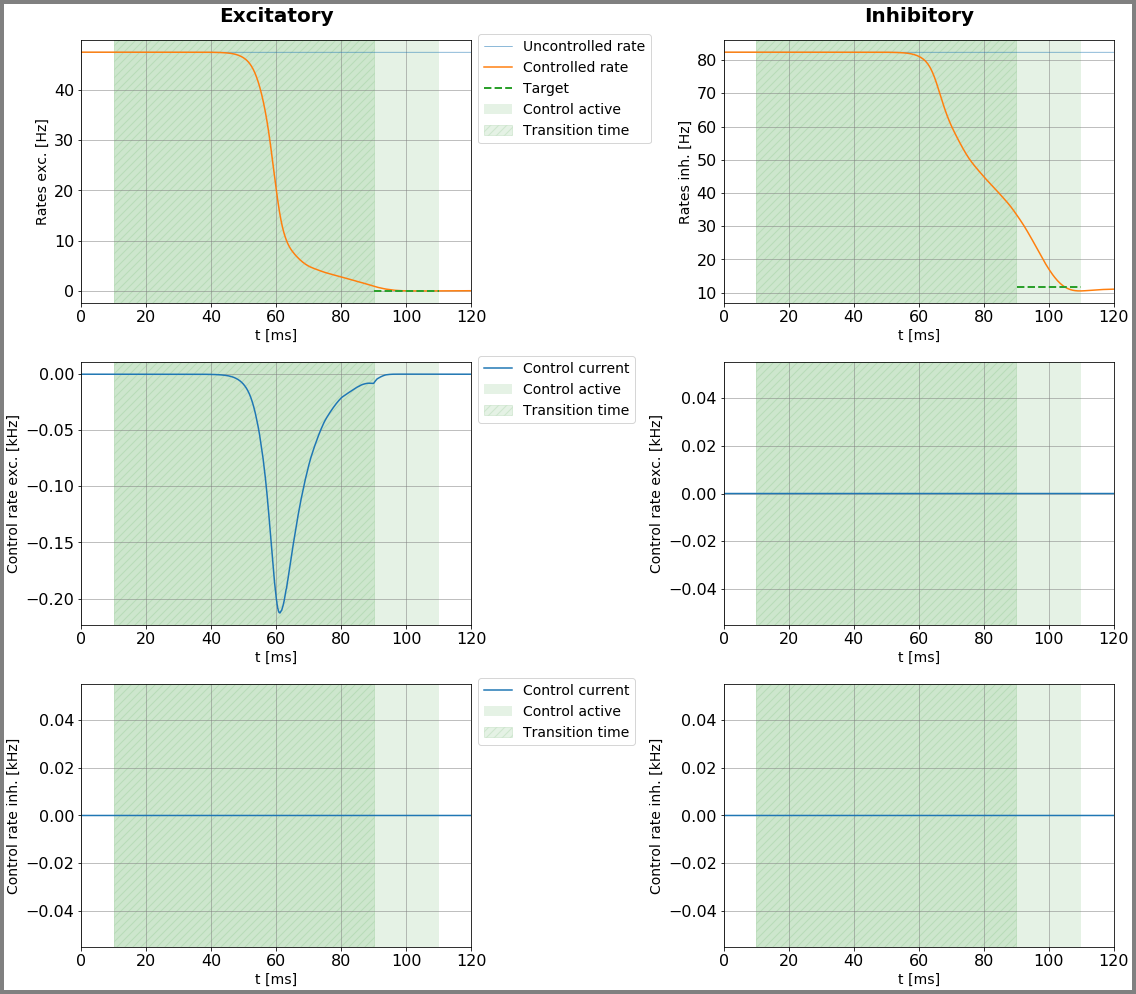

In [16]:
case_ind = 9
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 11

set cost params
control input:  [1, 2] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  150264.58031043285
RUN  0 , total integrated cost =  150264.58031043285
Improved over  0  iterations by  0.0  percent.


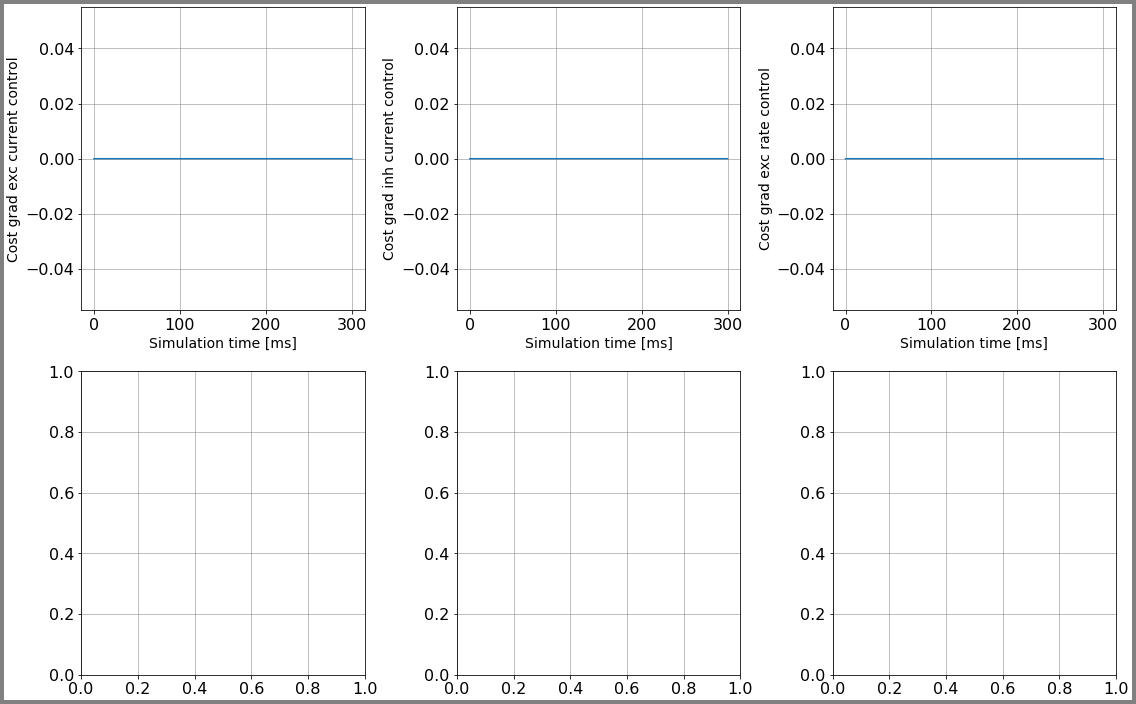

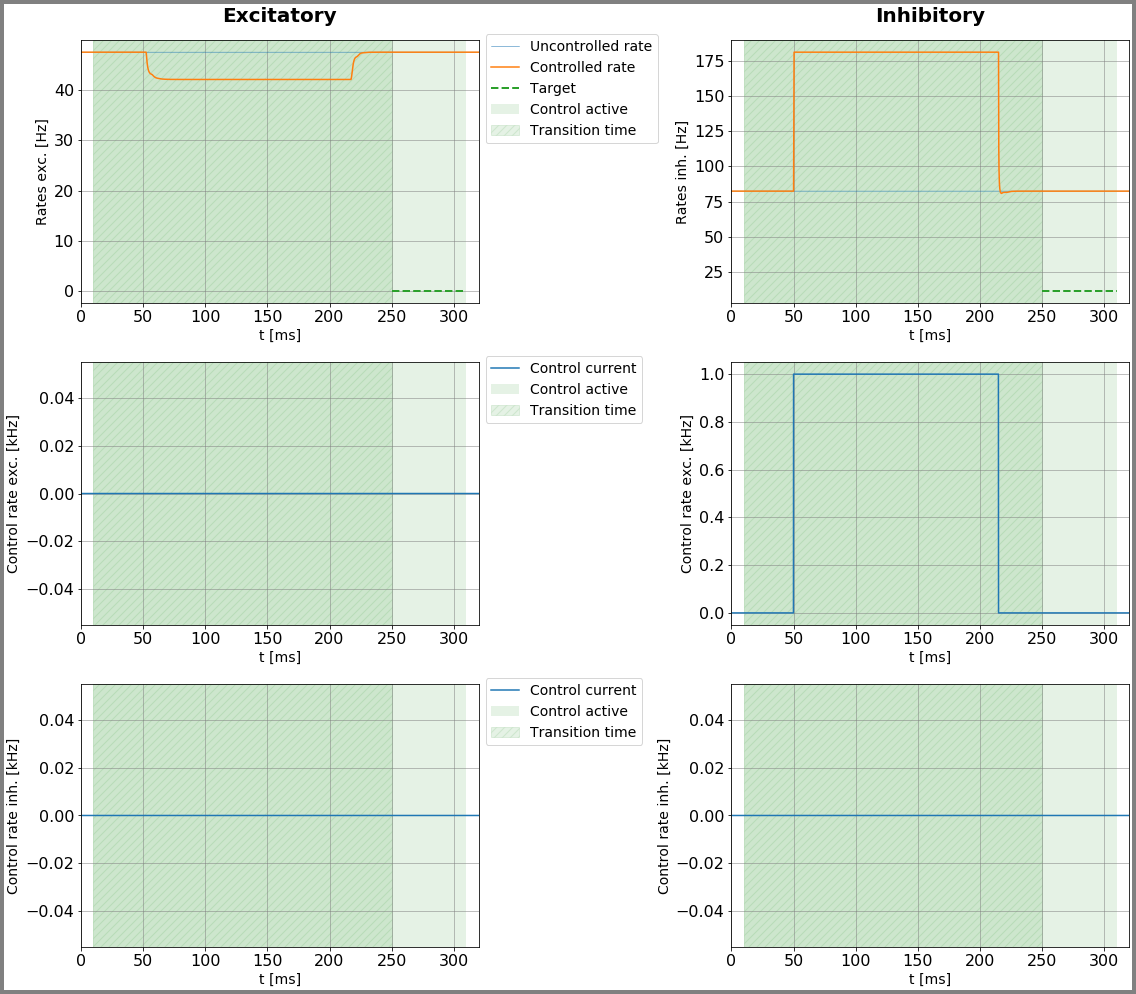

In [109]:
# A.10.a)
case_ind = 11
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,400:2050] = 5.
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 0

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  20713.97859171807
RUN  2 , total integrated cost =  20701.050679324457
RUN  3 , total integrated cost =  20700.7943291295
RUN  4 , total integrated cost =  20700.757542450257
RUN  5 , total integrated cost =  20700.749812818056
RUN  6 , total integrated cost =  20700.742311478356
RUN  7 , total integrated cost =  20700.73844357013
RUN  8 , total integrated cost =  20700.738374051147
RUN  9 , total integrated cost =  20700.737890955934
RUN  10 , total integrated cost =  20700.73655393961
RUN  11 , total integrated cost =  20700.736217142225
RUN  12 , total integrated cost =  20700.7356714599
RUN  13 , total integrated cost =  20700.735610154323
RUN  14 , total integrated cost =  20700.735378946294
RUN  15 , total integrated cost =  20700.735146926905
RUN  16 , total integrated cost =  20700.735095621214
RUN  17 , total integrated cost =  20700.7349

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  24 , total integrated cost =  20700.73435700526
Improved over  24  iterations by  7.970126721010942  percent.
Problem in initial value trasfer:  Vmean_exc -56.13984838129106 -56.141369803786674


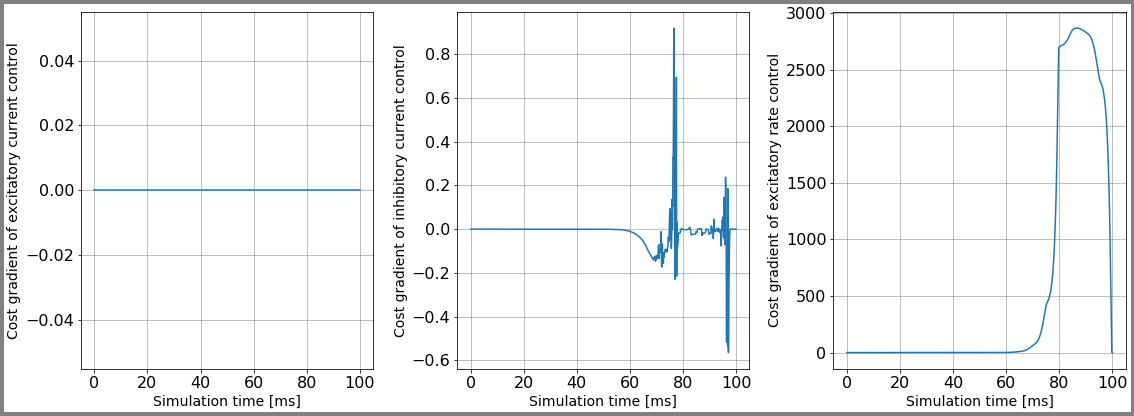

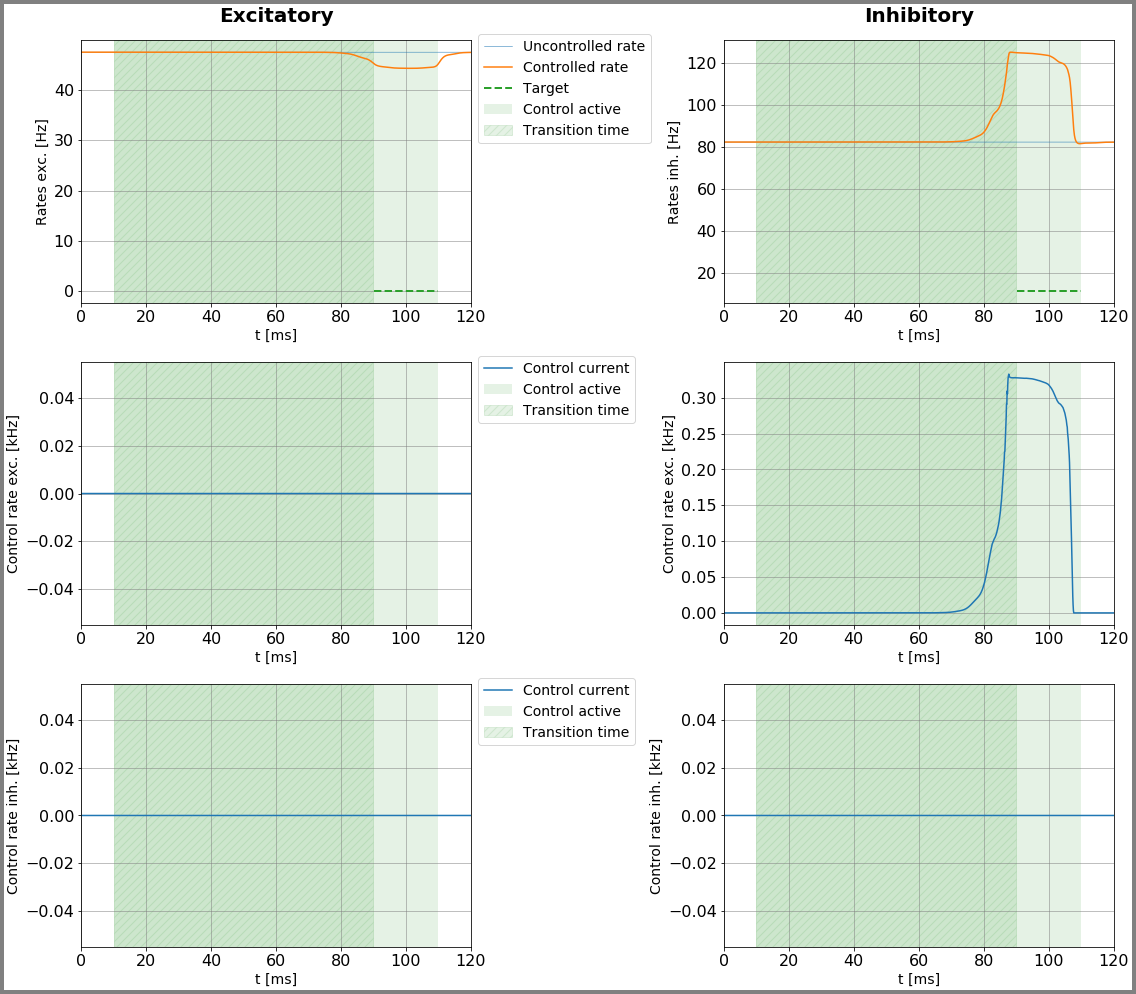

In [18]:
case_ind = 11
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 13

set cost params
control input:  [0, 1, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  0.06696649211560546
RUN  2 , total integrated cost =  0.06677795306452829
RUN  3 , total integrated cost =  0.06650382280064178
RUN  4 , total integrated cost =  0.06572277130532359
RUN  5 , total integrated cost =  0.06554468681689639
RUN  6 , total integrated cost =  0.06539782789036416
RUN  7 , total integrated cost =  0.06531466369663208
RUN  8 , total integrated cost =  0.06522676519469453
RUN  9 , total integrated cost =  0.06514151655564765
RUN  10 , total integrated cost =  0.06504990399960199
RUN  11 , total integrated cost =  0.0648604699952989
RUN  12 , total integrated cost =  0.0647315542886981
RUN  13 , total integrated cost =  0.06442090641366396
RUN  14 , total integrated cost =  0.06425852272578687
RUN  15 , total integrated cost =  0.06422139016890036
RUN  16 , total integrated 

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  0.003163182120730853
RUN  5000 , total integrated cost =  0.003163182120730853
Improved over  5000  iterations by  99.99998593734672  percent.
Problem in initial value trasfer:  Vmean_exc -58.57222626270469 -58.57713577113799


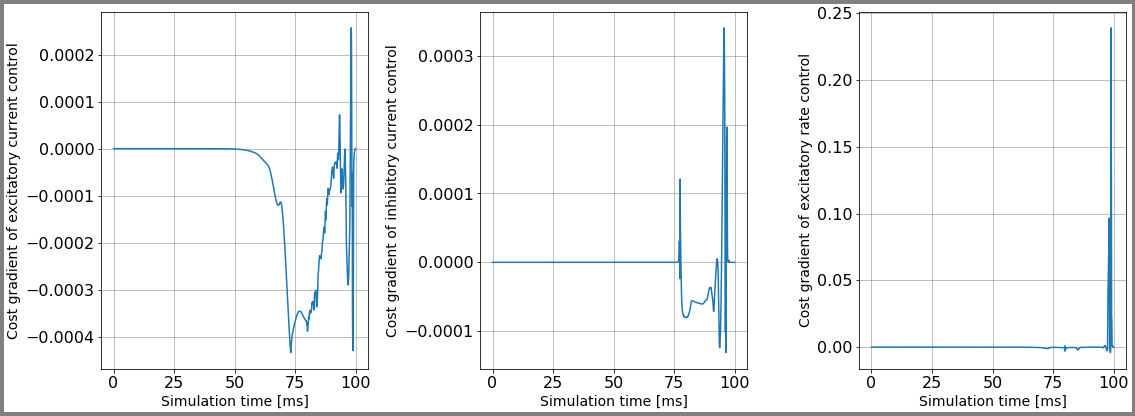

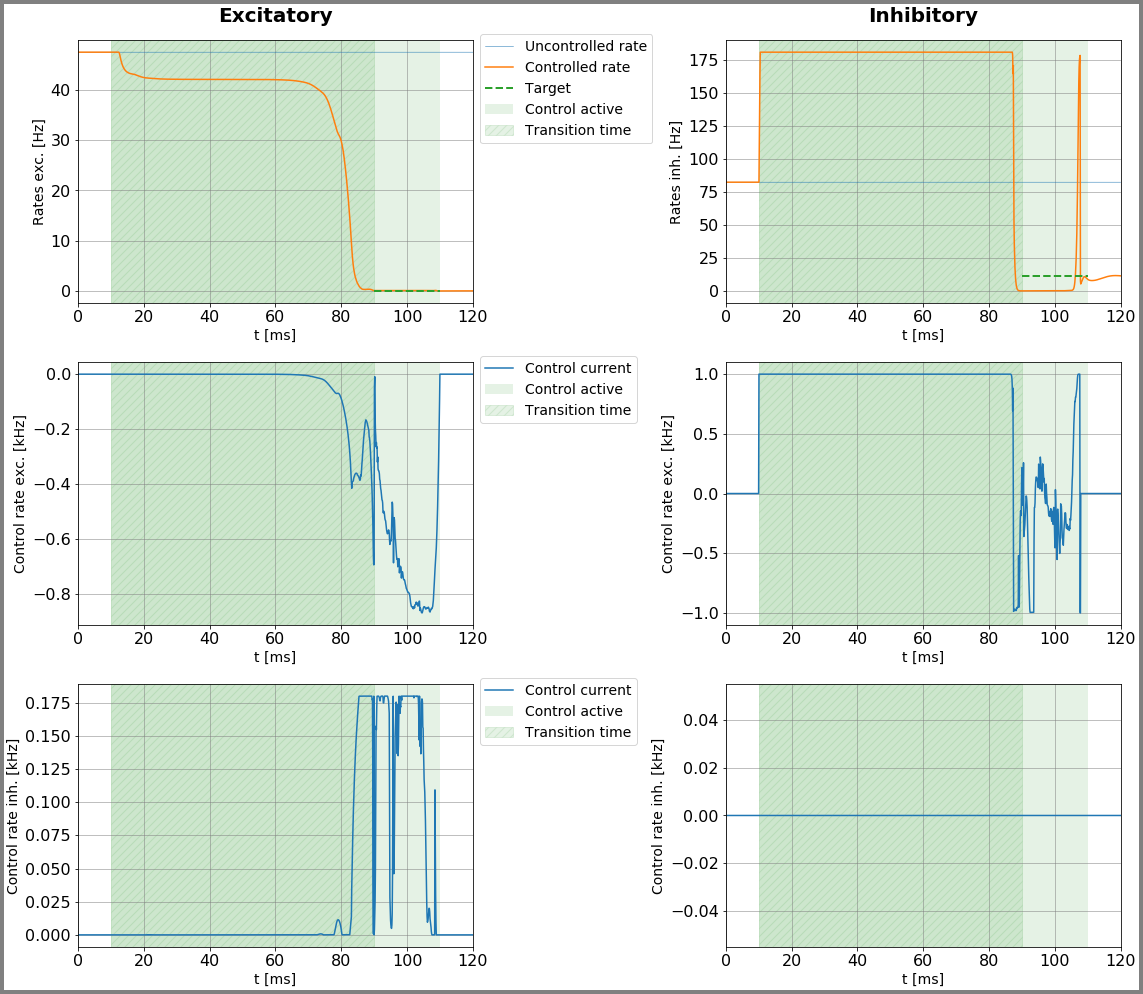

In [19]:
# A.12.a)
case_ind = 13
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  973.1494953914903
RUN  2 , total integrated cost =  723.7835266402074
RUN  3 , total integrated cost =  505.6419230191318
RUN  4 , total integrated cost =  450.66162414833434
RUN  5 , total integrated cost =  394.1221705582965
RUN  6 , total integrated cost =  371.44744577860035
RUN  7 , total integrated cost =  351.69352081768744
RUN  8 , total integrated cost =  341.1141172895118
RUN  9 , total integrated cost =  332.2077359764999
RUN  10 , total integrated cost =  326.70378610383216
RUN  11 , total integrated cost =  321.4449207744851
RUN  12 , total integrated cost =  318.0532952837113
RUN  13 , total integrated cost =  314.3555010291499
RUN  14 , total integrated cost =  312.19631432253806
RUN  15 , total integrated cost =  309.40676860740507
RUN  16 , total integrated cost =  307.5112010333213
RUN  17 , total integrated cost =  305.452471691

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1197 , total integrated cost =  231.8191673924916
Improved over  1197  iterations by  98.96939460065327  percent.
Problem in initial value trasfer:  Vmean_exc -57.15494658346237 -57.15274376866155


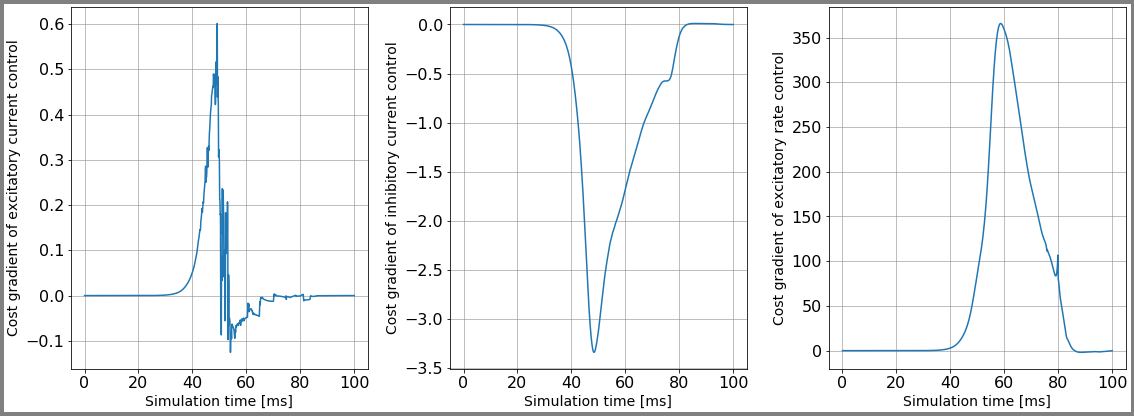

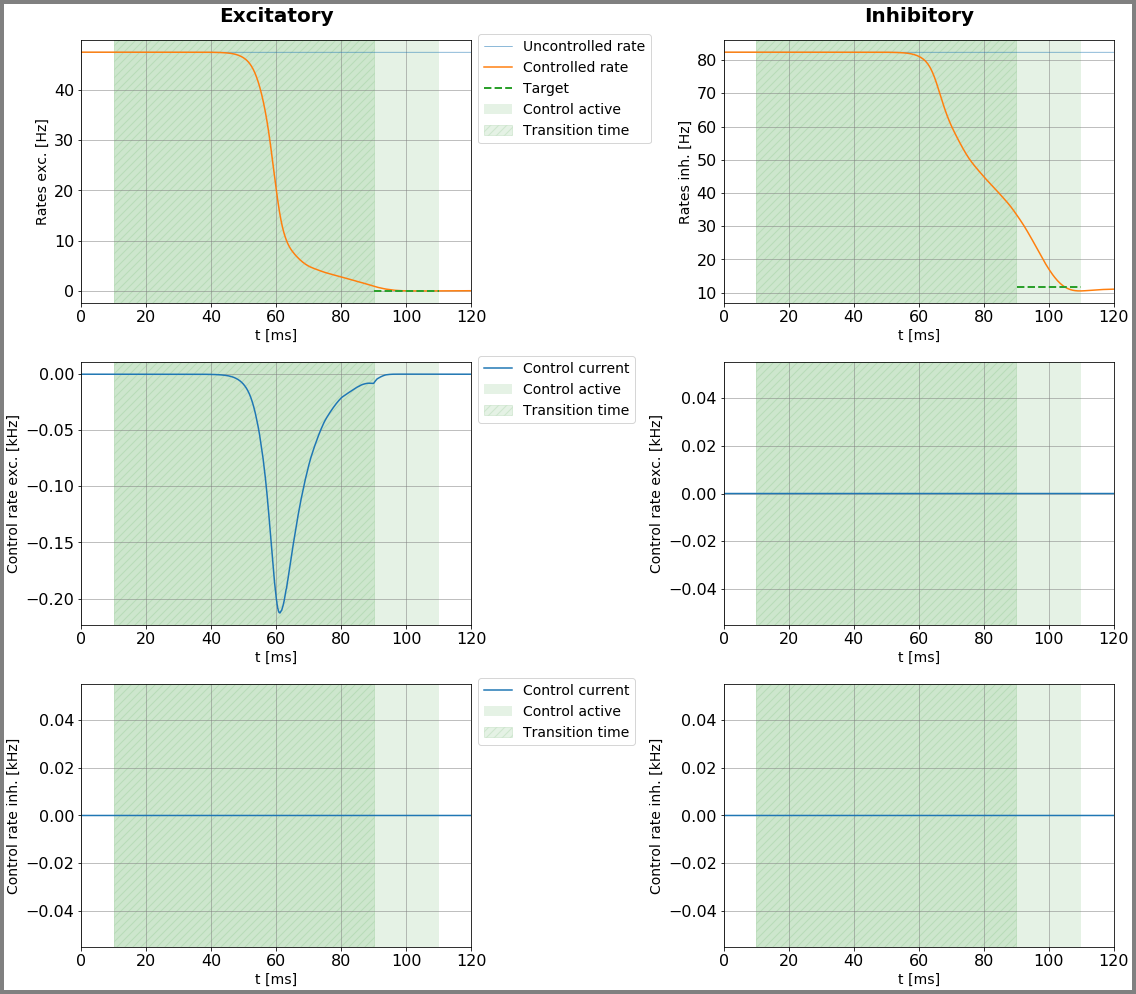

In [20]:
case_ind = 13
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )